# <center> **NIFTY 50 DATA ANALYSIS** </center>

**TIMELINE:**  ( 1st Jan 2025 - 31st Dec 2025 )

**DATASET:**   ( Nifty50_2025_Dataset )

**Importing Essential Libraries :**

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [4]:
import os
print(os.getcwd())

C:\Users\GUNGUN\Desktop\PYTHON\python assignment files


**Loading Dataset :**

In [5]:
import pandas as pd
df = pd.read_csv("Nifty50_2025.csv")

print(f"Dataset Shape: {df.shape}")
print(f"\nColumn Names:")
print(df.columns.tolist())
print(f"\nFirst 5 rows:")
df.head()

Dataset Shape: (62500, 18)

Column Names:
['Date', 'Session', 'Day_of_Week', 'Index', 'Company', 'Open', 'High', 'Low', 'Close', 'Previous_Close', '52_Week_High', '52_Week_Low', 'Gap', 'Gap_Percent', 'Gap_Type', 'Volume', 'Daily_Return_Percent', 'Intraday_Flag']

First 5 rows:


,Date,Session,Day_of_Week,Index,Company,Open,High,Low,Close,Previous_Close,52_Week_High,52_Week_Low,Gap,Gap_Percent,Gap_Type,Volume,Daily_Return_Percent,Intraday_Flag
0,01-01-2025,09:15-11:00,Wednesday,NIFTY_50,ADANIPORTS,2362.08,2370.94,2360.59,2362.94,2371.9,2720.33,1927.72,-9.82,-0.41,GAP_DOWN,120612,0.04,YES
1,01-01-2025,11:00-13:00,Wednesday,NIFTY_50,ADANIPORTS,2363.11,2365.15,2358.86,2363.79,2371.9,2720.33,1927.72,0.00,0.00,NO_GAP,96390,0.03,YES
2,01-01-2025,13:00-15:30,Wednesday,NIFTY_50,ADANIPORTS,2364.13,2376.06,2354.91,2364.64,2371.9,2720.33,1927.72,0.00,0.00,NO_GAP,120489,0.02,YES
3,01-01-2025,15:00-16:00,Wednesday,NIFTY_50,ADANIPORTS,2364.82,2372.28,2268.05,2273.65,2371.9,2720.33,1927.72,0.00,0.00,NO_GAP,18307,-3.86,YES
4,01-01-2025,Full_Day,Wednesday,NIFTY_50,ADANIPORTS,2362.08,2365.50,2267.91,2273.65,2371.9,2720.33,1927.72,-9.82,-0.41,GAP_DOWN,135022,-3.74,NO


**Data Info :**

In [6]:
print("Data Types:")
print(df.dtypes)
print(f"\nDataset Info:")
print(df.info())

Data Types:
Date                     object
Session                  object
Day_of_Week              object
Index                    object
Company                  object
Open                    float64
High                    float64
Low                     float64
Close                   float64
Previous_Close          float64
52_Week_High            float64
52_Week_Low             float64
Gap                     float64
Gap_Percent             float64
Gap_Type                 object
Volume                    int64
Daily_Return_Percent    float64
Intraday_Flag            object
dtype: object

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62500 entries, 0 to 62499
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Date                  62500 non-null  object 
 1   Session               62500 non-null  object 
 2   Day_of_Week           62500 non-null  object 
 3   Index         

**DATA EYEBALLING : ( CLEANING & FEATURE ENGINEERING )**

**Data Cleaning :**

In [7]:
print("DATA CLEANING")
print("="*60)

# 1. PRE-PROCESSING DATE COLUMN
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')
print("1. Date column converted to datetime")

# 2. PRE-PROCESSED DATE COLUMN TO EXTRACT DATE FEATURES
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Month_Name'] = df['Date'].dt.strftime('%B')
df['Day'] = df['Date'].dt.day
df['Week_Number'] = df['Date'].dt.isocalendar().week
print("2. Date features extracted (Year, Month, Month_Name, Day, Week_Number)")

# 3. CHECKING FOR NULL VALUES
print("\n3. Null Values Check:")
null_check = df.isnull().sum()
if null_check.sum() == 0:
    print("   No null values found - Clean dataset")
else:
    print(null_check[null_check > 0])

# 4. CHECKING DUPLICATES
dup_count = df.duplicated().sum()
print(f"\n4. Duplicate Rows: {dup_count}")

print("\n5. Final Data Types:")
print(df.dtypes)

# 5. DATASET SUMMARY
print(f"\n6. Dataset Summary:")
print(f"   Total rows: {len(df)}")
print(f"   Total columns: {len(df.columns)}")
print(f"   Date range: {df['Date'].min()} to {df['Date'].max()}")
print(f"   Companies List: {df['Company'].unique()}")
print(f"   Sessions: {df['Session'].unique()}")

# 6. NUMERICAL COLUMNS SUMMARY
print("\n7. Numerical Summary:")
print(df[['Open', 'High', 'Low', 'Close', 'Volume', 'Gap_Percent', 'Daily_Return_Percent']].describe().round(2))

# 7. CHECK FOR LOGICAL INCONSISTENCIES
high_low_check = (df['High'] >= df['Low']).all()
close_check = ((df['Close'] <= df['High']) & (df['Close'] >= df['Low'])).all()

print(f"\n8. Logical Validation:")
print(f"   High >= Low: {high_low_check}")
print(f"   Close within High-Low: {close_check}")

DATA CLEANING
1. Date column converted to datetime
2. Date features extracted (Year, Month, Month_Name, Day, Week_Number)

3. Null Values Check:
   No null values found - Clean dataset

4. Duplicate Rows: 0

5. Final Data Types:
Date                    datetime64[ns]
Session                         object
Day_of_Week                     object
Index                           object
Company                         object
Open                           float64
High                           float64
Low                            float64
Close                          float64
Previous_Close                 float64
52_Week_High                   float64
52_Week_Low                    float64
Gap                            float64
Gap_Percent                    float64
Gap_Type                        object
Volume                           int64
Daily_Return_Percent           float64
Intraday_Flag                   object
Year                             int32
Month                         

**Feature Engineering :**

In [105]:
# Intraday Flag Distribution
df['Intraday_Flag'] = ((df['High'] - df['Low']) / df['Open'] * 100).round(2)

# Gap Analysis
df['Gap_Percent'] = ((df['Open'] - df['Close'].shift(1)) / df['Close'].shift(1) * 100).round(2)

# Gap Type
def assign_gap_type(gap):
    if gap > 0.5:
        return 'GAP_UP'
    elif gap < -0.5:
        return 'GAP_DOWN'
    else:
        return 'NO_GAP'

df['Gap_Type'] = df['Gap_Percent'].apply(assign_gap_type)

# Daily Return Statistics
df['Daily_Return'] = ((df['Close'] - df['Open']) / df['Open'] * 100).round(2)

# Previous Close Return
df['Prev_Close_Return'] = ((df['Close'] - df['Close'].shift(1)) / df['Close'].shift(1) * 100).round(2)

# Distance from 52-Week High 
if '52_Week_High' in df.columns:
    df['Distance_from_52W_High'] = ((df['52_Week_High'] - df['Close']) / df['52_Week_High'] * 100).round(2)

# Distance from 52-Week Low
if '52_Week_Low' in df.columns:
    df['Distance_from_52W_Low'] = ((df['Close'] - df['52_Week_Low']) / df['52_Week_Low'] * 100).round(2)

print(df[['Date', 'Month_Name', 'Day_of_Week', 'Intraday_Flag', 'Gap_Type', 'Daily_Return']].head(10))

        Date Month_Name Day_of_Week  Intraday_Flag  Gap_Type  Daily_Return
0 2025-01-01    January   Wednesday           0.44    NO_GAP          0.04
1 2025-01-01    January   Wednesday           0.27    NO_GAP          0.03
2 2025-01-01    January   Wednesday           0.89    NO_GAP          0.02
3 2025-01-01    January   Wednesday           4.41    NO_GAP         -3.86
4 2025-01-01    January   Wednesday           4.13    GAP_UP         -3.74
5 2025-01-01    January   Wednesday           1.27    GAP_UP          0.94
6 2025-01-01    January   Wednesday           1.18    NO_GAP          0.75
7 2025-01-01    January   Wednesday           0.81    NO_GAP          0.55
8 2025-01-01    January   Wednesday           0.55    NO_GAP          0.04
9 2025-01-01    January   Wednesday           4.73  GAP_DOWN          3.06


## **BUSINESS PROBLEMS **

**1. Which companies show highest intraday volatility?**

**2. Which companies have most daily trading activity?**

**3. Which session has highest volume activity?**

**4. Which companies have largest daily price ranges?**

**5. Which companies give best/worst returns?**

**6. What percentage of days are bullish vs bearish?**

**7. Which months have highest trading activity?**

**8. Which companies have most extreme daily gains/losses?**

**9. How frequently do Gap Up and Gap Down occur?**

**10. Which days have best/worst average returns?**

**11. Which months show best/worst performance?**

**12. What percentage distance is price from 52-week extremes?**

**13. How does volatility change across the month?**

**14. What's the distribution of trading volumes?**



## <center> **ANALYSIS ** </center>

**INTRADAY VOLATILITY ANALYSIS**

**Problem: Measure daily price movement to identify volatile stocks.**

**Question: Which companies show highest intraday volatility?**

In [8]:
print("\n\nINTRADAY VOLATILITY ANALYSIS")
print("-"*60)

df['Intraday_Flag'] = ((df['High'] - df['Low']) / df['Open'] * 100).round(2)

print(f"Average Volatility: {df['Intraday_Flag'].mean():.2f}%")
print(f"Max Volatility: {df['Intraday_Flag'].max():.2f}%")

print("\nTop 10 Most Volatile Companies:")
vol_company = df.groupby('Company')['Intraday_Flag'].mean().sort_values(ascending=False)
print(vol_company.head(10).round(2))




INTRADAY VOLATILITY ANALYSIS
------------------------------------------------------------
Average Volatility: 1.54%
Max Volatility: 11.66%

Top 10 Most Volatile Companies:
Company
BAJFINANCE    1.62
COLPAL        1.60
LTIM          1.60
HDFCBANK      1.59
JSWSTEEL      1.59
LANDT         1.58
GRASIM        1.58
COALINDIA     1.58
DRREDDY       1.57
RELIANCE      1.56
Name: Intraday_Flag, dtype: float64


*-----------------------------------------------------------------------------------------------------------------------------------------------------*

**(COMPANY LIQUIDITY RANKING) TOP VOLUME COMPANIES**

**Problem: Identify companies with highest trading volume.**

**Question: Which companies have most daily trading activity?**



TOP VOLUME COMPANIES
------------------------------------------------------------

Top 5 Most Traded Companies:
            Avg_Volume  Median_Volume  Max_Volume
Company                                          
HDFCBANK      117174.0        94428.0      499887
ICICIBANK     116998.0        94293.0      498455
TATASTEEL     116337.0        91231.0      499954
INFY          116222.0        92890.0      496537
SHREECEM      116111.0        92243.0      499712
HCLTECH       115911.0        92192.0      499224
JSWSTEEL      115606.0        95688.0      499122
SBIN          115586.0        91319.0      495369
ASIANPAINT    115056.0        91598.0      497800
DIVISLAB      114946.0        88573.0      496901


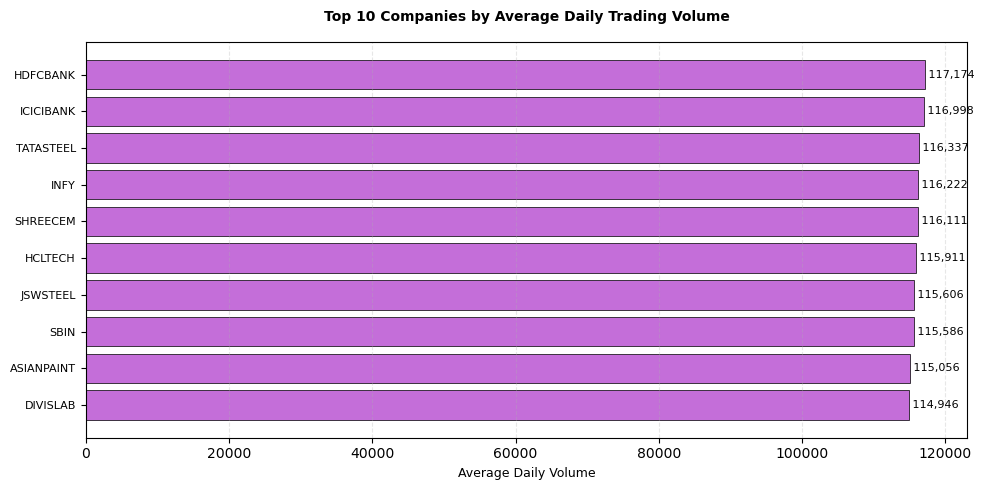

In [9]:
print("\n\nTOP VOLUME COMPANIES")
print("-"*60)

company_volume_stats = df.groupby('Company')['Volume'].agg(['mean', 'median', 'max']).round(0).sort_values('mean', ascending=False)
company_volume_stats.columns = ['Avg_Volume', 'Median_Volume', 'Max_Volume']

print(f"\nTop 5 Most Traded Companies:")
print(company_volume_stats.head(10))

# Visualization 
fig, ax = plt.subplots(figsize=(10, 5))

top_10_vol = company_volume_stats.head(10)['Avg_Volume'].sort_values(ascending=True)

ax.barh(range(len(top_10_vol)), top_10_vol.values, color='#BA55D3', edgecolor='black', linewidth=0.6, alpha=0.85)
ax.set_yticks(range(len(top_10_vol)))
ax.set_yticklabels(top_10_vol.index, fontsize=8)
ax.set_xlabel('Average Daily Volume', fontsize=9)
ax.set_title('Top 10 Companies by Average Daily Trading Volume', fontsize=10, fontweight='bold', pad=15)
ax.grid(axis='x', alpha=0.3, linestyle='--')

for i, v in enumerate(top_10_vol.values):
    ax.text(v, i, f' {v:,.0f}', va='center', fontsize=8)

plt.tight_layout()
plt.show()

*-----------------------------------------------------------------------------------------------------------------------------------------------------*

**VOLUME BY SESSION**

**Problem: Compare trading volume across different sessions.**

**Question: Which session has highest volume activity?**



 VOLUME BY SESSION
------------------------------------------------------------
Volume Statistics by Session:
             Avg_Volume  Median_Volume  Max_Volume  Trading_Days
Session                                                         
09:15-11:00     77093.0        77048.0      149996         12500
11:00-13:00     77994.0        78379.0      149991         12500
13:00-15:30     77365.0        77126.0      149989         12500
15:00-16:00     77069.0        76636.0      149996         12500
Full_Day       254702.0       255680.0      499988         12500

Highest Volume Session: Full_Day (254,702 shares)


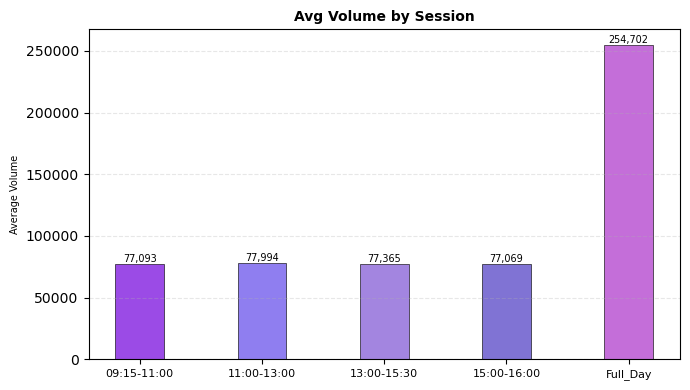

In [10]:
print("\n\n VOLUME BY SESSION")
print("-"*60)

print("Volume Statistics by Session:")
session_volume = df.groupby('Session')['Volume'].agg(['mean', 'median', 'max', 'count']).round(0)
session_volume.columns = ['Avg_Volume', 'Median_Volume', 'Max_Volume', 'Trading_Days']

print(session_volume)

best_volume_session = session_volume['Avg_Volume'].idxmax()
print(f"\nHighest Volume Session: {best_volume_session} ({session_volume.loc[best_volume_session, 'Avg_Volume']:,.0f} shares)")

# Visualization 
fig, ax = plt.subplots(figsize=(7, 4))

sessions = session_volume.index
volumes = session_volume['Avg_Volume'].values

colors_session = ['#8A2BE2', '#7B68EE', '#9370DB', '#6A5ACD', '#BA55D3']

bars = ax.bar(range(len(sessions)), volumes,
              color=colors_session[:len(sessions)],
              edgecolor='black',
              linewidth=0.5,
              alpha=0.85,
              width=0.4)

ax.set_xticks(range(len(sessions)))
ax.set_xticklabels(sessions, fontsize=8)

ax.set_ylabel('Average Volume', fontsize=7)
ax.set_title('Avg Volume by Session', fontsize=10, fontweight='bold')

ax.grid(axis='y', alpha=0.3, linestyle='--')

for i, v in enumerate(volumes):
    ax.text(i, v, f'{v:,.0f}', ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.show()

*-----------------------------------------------------------------------------------------------------------------------------------------------------*

**PRICE RANGE BY COMPANY**

**Problem: Measure daily price range (High-Low) for each company.**

**Question: Which companies have largest daily price ranges?**

In [12]:
print("\n\nPRICE RANGE BY TOP 10 COMPANIES")
print("-"*60)

df['Daily_Price_Range'] = df['High'] - df['Low']
df['Daily_Price_Range_Pct'] = (df['Daily_Price_Range'] / df['Open'] * 100).round(2)

company_price_range = df.groupby('Company')['Daily_Price_Range_Pct'].agg(['mean', 'max', 'min']).round(2).sort_values('mean', ascending=False)
company_price_range.columns = ['Avg_Range_%', 'Max_Range_%', 'Min_Range_%']

print(company_price_range.head(10))



PRICE RANGE BY TOP 10 COMPANIES
------------------------------------------------------------
            Avg_Range_%  Max_Range_%  Min_Range_%
Company                                          
BAJFINANCE         1.62         8.61         0.08
LTIM               1.60        10.43         0.09
COLPAL             1.60         9.53         0.08
JSWSTEEL           1.59         9.54         0.08
HDFCBANK           1.59        11.00         0.06
GRASIM             1.58         9.55         0.07
LANDT              1.58         9.35         0.07
COALINDIA          1.58         9.08         0.07
DRREDDY            1.57        11.66         0.11
MARUTI             1.56        10.18         0.12


*-----------------------------------------------------------------------------------------------------------------------------------------------------*

**RETURNS BY COMPANY**

**Problem: Calculate average daily returns for each company.**

**Question: Which companies give best/worst returns?**



RETURNS BY COMPANY
------------------------------------------------------------

Top 5 Best Returning Companies:
            Avg_Return_%  Volatility_%  Min_Return_%  Max_Return_%
Company                                                           
SUNPHARMA           0.13          1.45         -8.89          7.05
SBIN                0.07          1.45         -7.77          7.28
POWERGRID           0.05          1.55         -9.36          8.16
WIPRO               0.04          1.49         -7.80          5.66
BHARTIARTL          0.04          1.43         -7.30          7.82

Top 5 Worst Returning Companies:
            Avg_Return_%  Volatility_%  Min_Return_%  Max_Return_%
Company                                                           
SHREECEM           -0.09          1.38         -6.74          5.33
ADANIPORTS         -0.09          1.54         -7.87          7.01
HINDALCO           -0.10          1.49         -8.74          7.36
JSWSTEEL           -0.11          1.58         

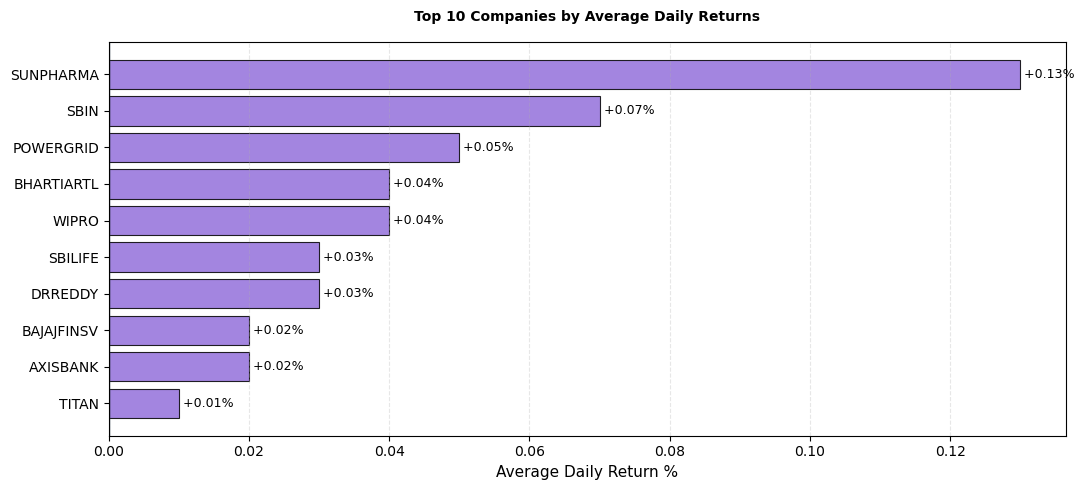

In [15]:
print("\n\nRETURNS BY COMPANY")
print("-"*60)

company_returns = df.groupby('Company')['Daily_Return_Percent'].agg(['mean', 'std', 'min', 'max']).round(2).sort_values('mean', ascending=False)
company_returns.columns = ['Avg_Return_%', 'Volatility_%', 'Min_Return_%', 'Max_Return_%']

print(f"\nTop 5 Best Returning Companies:")
print(company_returns.head(5))

print(f"\nTop 5 Worst Returning Companies:")
print(company_returns.tail(5))

# Visualization
fig, ax = plt.subplots(figsize=(11, 5))

top_10_returns = company_returns.head(10)['Avg_Return_%'].sort_values()
colors_return = ['#9370DB' if x > 0 else '#C9A882' for x in top_10_returns.values]

ax.barh(range(len(top_10_returns)), top_10_returns.values, color=colors_return, edgecolor='black', linewidth=0.8, alpha=0.85)
ax.set_yticks(range(len(top_10_returns)))
ax.set_yticklabels(top_10_returns.index, fontsize=10)
ax.axvline(x=0, color='#2C3E50', linestyle='-', linewidth=1)
ax.set_xlabel('Average Daily Return %', fontsize=11)
ax.set_title('Top 10 Companies by Average Daily Returns', fontsize=10, fontweight='bold', pad=15)
ax.grid(axis='x', alpha=0.3, linestyle='--')

for i, v in enumerate(top_10_returns.values):
    sign = '+' if v > 0 else ''
    ax.text(v, i, f' {sign}{v:.2f}%', va='center', fontsize=9)

plt.tight_layout()
plt.show()


*-----------------------------------------------------------------------------------------------------------------------------------------------------*

**POSITIVE VS NEGATIVE DAYS**

**Problem: Count days with positive, negative, and zero returns.**

**Question: What percentage of days are bullish vs bearish?**



POSITIVE VS NEGATIVE DAYS
------------------------------------------------------------
Return Days Distribution:
  Positive Days: 46160 (73.86%)
  Negative Days: 15786 (25.26%)
  Zero Return Days: 554 (0.89%)

Average Returns by Category:
  Positive Days Avg: 0.58%
  Negative Days Avg: -1.81%


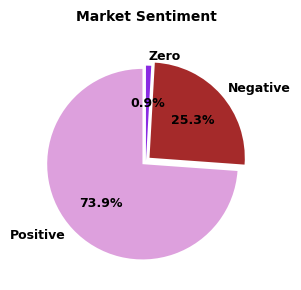

In [17]:
print("\n\nPOSITIVE VS NEGATIVE DAYS")
print("-"*60)

positive_days = (df['Daily_Return_Percent'] > 0).sum()
negative_days = (df['Daily_Return_Percent'] < 0).sum()
zero_days = (df['Daily_Return_Percent'] == 0).sum()

total_days = len(df)

print("Return Days Distribution:")
print(f"  Positive Days: {positive_days} ({positive_days/total_days*100:.2f}%)")
print(f"  Negative Days: {negative_days} ({negative_days/total_days*100:.2f}%)")
print(f"  Zero Return Days: {zero_days} ({zero_days/total_days*100:.2f}%)")

print(f"\nAverage Returns by Category:")
print(f"  Positive Days Avg: {df[df['Daily_Return_Percent'] > 0]['Daily_Return_Percent'].mean():.2f}%")
print(f"  Negative Days Avg: {df[df['Daily_Return_Percent'] < 0]['Daily_Return_Percent'].mean():.2f}%")

# Visualization
fig, ax = plt.subplots(figsize=(6, 3))

return_counts = [positive_days, negative_days, zero_days]
labels = ['Positive', 'Negative', 'Zero']
colors_return_pie = ['#DDA0DD', '#A52A2A', '#8A2BE2']
explode = (0.05, 0.05, 0)

wedges, texts, autotexts = ax.pie(
    return_counts,
    labels=labels,
    autopct='%1.1f%%',
    colors=colors_return_pie,
    explode=explode,
    startangle=90,
    textprops={'fontsize': 9, 'weight': 'bold'}
)

ax.set_title('Market Sentiment', fontsize=10, fontweight='bold', pad=15)

for autotext in autotexts:
    autotext.set_color('black')

plt.tight_layout()
plt.show()

*-----------------------------------------------------------------------------------------------------------------------------------------------------*

**MONTH-WISE VOLUME**

**Problem: Analyze trading volume trends across months.**

**Question: Which months have highest trading activity?**

In [16]:
print("\n\n MONTH-WISE AVERAGE VOLUME")
print("-"*60)

month_order = ['January', 'February', 'March', 'April', 'May', 'June', 
               'July', 'August', 'September', 'October', 'November', 'December']
monthly_volume = df.groupby('Month_Name')['Volume'].agg(['mean']).round(0)
monthly_volume = monthly_volume.reindex([m for m in month_order if m in monthly_volume.index])
monthly_volume.columns = ['Avg_Volume']

print(monthly_volume)

highest_volume_month = monthly_volume['Avg_Volume'].idxmax()
print(f"\nHighest Volume Month: {highest_volume_month}")



 MONTH-WISE AVERAGE VOLUME
------------------------------------------------------------
            Avg_Volume
Month_Name            
January       113040.0
February      113565.0
March         113376.0
April         113294.0
May           112253.0
June          111504.0
July          113653.0
August        113221.0
September     113906.0
October       112168.0
November      113018.0
December      111256.0

Highest Volume Month: September


*-----------------------------------------------------------------------------------------------------------------------------------------------------*

**COMPANY CONSISTENCY (BEST & WORST DAYS)**
                       
**Problem: Identify which companies have best and worst single-day performance.**
    
**Question: Which companies have most extreme daily gains/losses?**



COMPANY CONSISTENCY (BEST & WORST DAYS)
------------------------------------------------------------

Companies with Highest Gains:
            Best_Day_%
Company               
DRREDDY          10.42
BAJAJ-AUTO        9.28
LTIM              9.27
HDFCBANK          8.79
GODREJCP          8.56

Companies with Largest Losses:
            Worst_Day_%
Company                
HEROMOTOCO        -7.14
AUROPHARMA        -6.57
ONGC              -8.41
WIPRO             -7.80
SHREECEM          -6.74


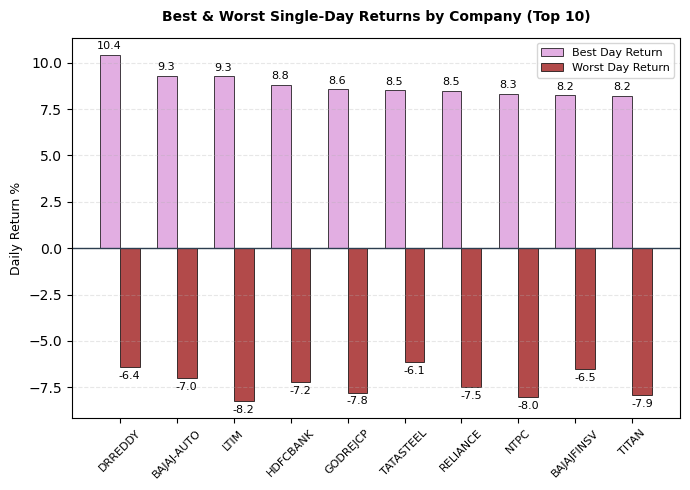

In [19]:
print("\n\nCOMPANY CONSISTENCY (BEST & WORST DAYS)")
print("-"*60)

company_extremes = df.groupby('Company')['Daily_Return_Percent'].agg(['max', 'min']).round(2).sort_values('max', ascending=False)
company_extremes.columns = ['Best_Day_%', 'Worst_Day_%']

print(f"\nCompanies with Highest Gains:")
print(company_extremes.head(5)[['Best_Day_%']])

print(f"\nCompanies with Largest Losses:")
print(company_extremes.tail(5)[['Worst_Day_%']])

# Visualization
fig, ax = plt.subplots(figsize=(7, 5))

top_10_extreme = company_extremes.head(10)

x = np.arange(len(top_10_extreme))
width = 0.35

bars1 = ax.bar(x - width/2, top_10_extreme['Best_Day_%'], width,
               label='Best Day Return', color='#DDA0DD',
               edgecolor='black', linewidth=0.6, alpha=0.85)

bars2 = ax.bar(x + width/2, top_10_extreme['Worst_Day_%'], width,
               label='Worst Day Return', color='#A52A2A',
               edgecolor='black', linewidth=0.6, alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(top_10_extreme.index, fontsize=8, rotation=45)
ax.axhline(y=0, color='#2C3E50', linestyle='-', linewidth=1)

ax.set_ylabel('Daily Return %', fontsize=9)
ax.set_title('Best & Worst Single-Day Returns by Company (Top 10)',
             fontsize=10, fontweight='bold', pad=12)

ax.legend(fontsize=8)
ax.grid(axis='y', alpha=0.3, linestyle='--')

for bar in bars1:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2,
            height + 0.2,                
            f'{height:.1f}',
            ha='center', va='bottom', fontsize=8)

for bar in bars2:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2,
            height - 0.2,                 
            f'{height:.1f}',
            ha='center', va='top', fontsize=8)

plt.tight_layout()
plt.show()

*------------------------------------------------------------------------------------------------------------------------------------------------------*

# <center> **DASHBOARD - 1** </center>

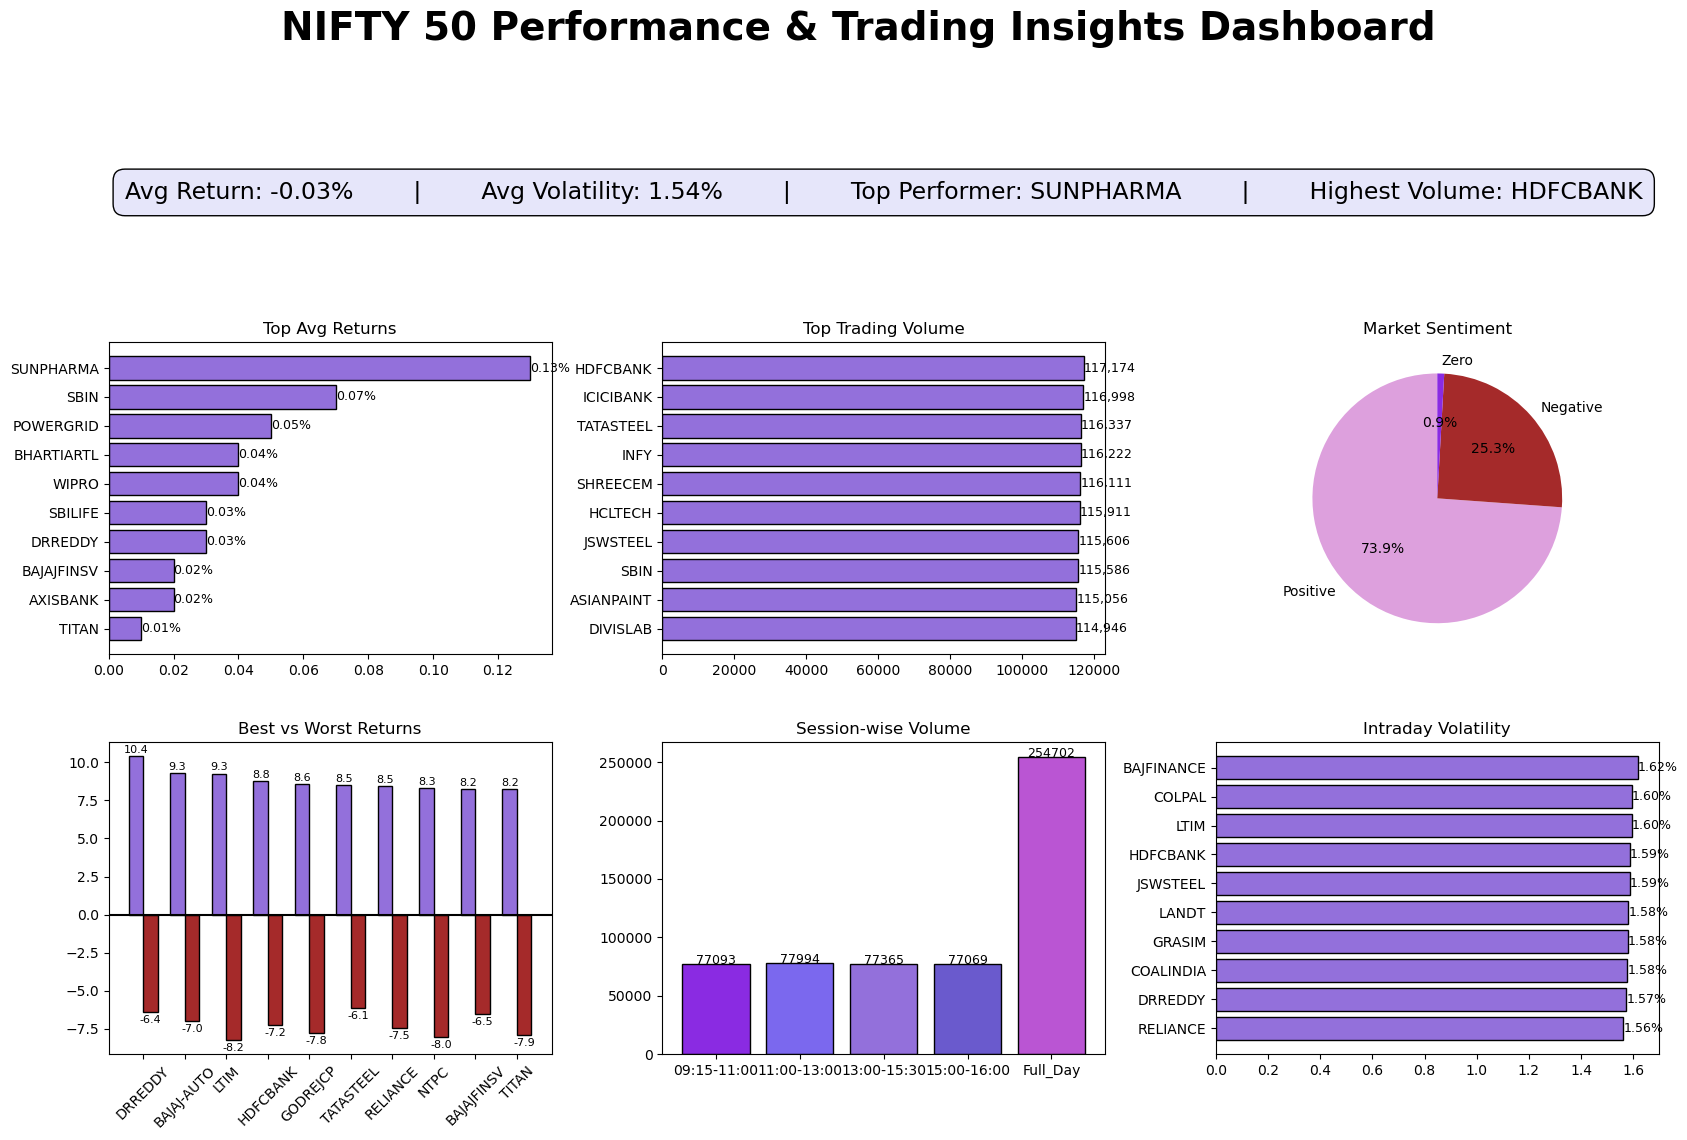

In [21]:
# ---------------------------------------------------- DASHBOARD - 1 ------------------------------------------------------
                   # -------------------------------------------------------------------------------#
# ------------------ COLORS ------------------
color_main = '#9370DB'
color_negative = '#A52A2A'

# ------------------ KPI VALUES ------------------
avg_return = company_returns['Avg_Return_%'].mean()
avg_volatility = df['Intraday_Flag'].mean()
top_company = company_returns['Avg_Return_%'].idxmax()
top_volume_company = company_volume_stats['Avg_Volume'].idxmax()

# ------------------ FIGURE ------------------
fig = plt.figure(figsize=(20, 12))
fig.suptitle("NIFTY 50 Performance & Trading Insights Dashboard",
             fontsize=28, fontweight='bold')

gs = fig.add_gridspec(3, 3, height_ratios=[0.4, 1, 1], hspace=0.35, wspace=0.25)

# ------------------ KPI CARDS ------------------
ax_kpi = fig.add_subplot(gs[0, :])
ax_kpi.axis('off')

kpi_text = (
    f"Avg Return: {avg_return:.2f}%        |        "
    f"Avg Volatility: {avg_volatility:.2f}%        |        "
    f"Top Performer: {top_company}        |        "
    f"Highest Volume: {top_volume_company}"
)

ax_kpi.text(0.5, 0.5, kpi_text, ha='center', va='center',
            fontsize=17, bbox=dict(facecolor='#E6E6FA', boxstyle='round,pad=0.5'))

# ------------------ (1) RETURNS ------------------
ax1 = fig.add_subplot(gs[1, 0])
top_10_returns = company_returns.head(10)['Avg_Return_%'].sort_values()

ax1.barh(top_10_returns.index, top_10_returns.values,
         color=color_main, edgecolor='black')

ax1.set_title("Top Avg Returns")

for i, v in enumerate(top_10_returns.values):
    ax1.text(v, i, f'{v:.2f}%', va='center', fontsize=9)

# ------------------ (2) VOLUME ------------------
ax2 = fig.add_subplot(gs[1, 1])
top_10_vol = company_volume_stats.head(10)['Avg_Volume'].sort_values()

ax2.barh(top_10_vol.index, top_10_vol.values,
         color=color_main, edgecolor='black')

for i, v in enumerate(top_10_vol.values):
    ax2.text(v, i,
             f'{v:,.0f}',      # comma format (e.g., 1,20,000)
             va='center',
             fontsize=9)
    
ax2.set_title("Top Trading Volume")

# ------------------ (3) PIE ------------------
ax3 = fig.add_subplot(gs[1, 2])

return_counts = [positive_days, negative_days, zero_days]
labels = ['Positive', 'Negative', 'Zero']

wedges, texts, autotexts = ax3.pie(return_counts,
                                   labels=labels,
                                   autopct='%1.1f%%',
                                   colors=['#DDA0DD', '#A52A2A', '#8A2BE2'],
                                   startangle=90)

for t in autotexts:
    t.set_color('black')

ax3.set_title("Market Sentiment")

# ------------------ (4) BEST vs WORST ------------------
ax4 = fig.add_subplot(gs[2, 0])

top_10_extreme = company_extremes.head(10)
x = np.arange(len(top_10_extreme))
width = 0.35

bars1 = ax4.bar(x - width/2, top_10_extreme['Best_Day_%'], width,
                color=color_main, edgecolor='black')

bars2 = ax4.bar(x + width/2, top_10_extreme['Worst_Day_%'], width,
                color=color_negative, edgecolor='black')

ax4.set_xticks(x)
ax4.set_xticklabels(top_10_extreme.index, rotation=45)
ax4.set_title("Best vs Worst Returns")
ax4.axhline(0, color='black')

# labels
for bar in bars1:
    h = bar.get_height()
    ax4.text(bar.get_x()+bar.get_width()/2, h+0.2, f'{h:.1f}', ha='center', fontsize=8)

for bar in bars2:
    h = bar.get_height()
    ax4.text(bar.get_x()+bar.get_width()/2, h-0.2, f'{h:.1f}', ha='center', va='top', fontsize=8)

# ------------------ (5) SESSION ------------------
ax5 = fig.add_subplot(gs[2, 1])
colors_session = ['#8A2BE2', '#7B68EE', '#9370DB', '#6A5ACD', '#BA55D3']
bars = ax5.bar(session_volume.index,
               session_volume['Avg_Volume'],
               color=colors_session, edgecolor='black')

ax5.set_title("Session-wise Volume")

for i, v in enumerate(session_volume['Avg_Volume']):
    ax5.text(i, v, f'{v:.0f}', ha='center', fontsize=9)

# ------------------ (6) VOLATILITY ------------------
ax6 = fig.add_subplot(gs[2, 2])

top_10_volatility = vol_company.head(10).sort_values()

ax6.barh(top_10_volatility.index, top_10_volatility.values,
         color=color_main, edgecolor='black')

ax6.set_title("Intraday Volatility")

for i, v in enumerate(top_10_volatility.values):
    ax6.text(v, i, f'{v:.2f}%', va='center', fontsize=9)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

*-----------------------------------------------------------------------------------------------------------------------------------------------------*

**GAP UP-GAP DOWN ANALYSIS**

**Problem: Identify opening gaps to assess market sentiment shifts.**

**Question: How frequently do Gap Up and Gap Down occur?**



GAP UP-GAP DOWN ANALYSIS
------------------------------------------------------------
Gap Type Distribution:
  NO_GAP: 39,080 days (62.53%)
  GAP_UP: 12,218 days (19.55%)
  GAP_DOWN: 11,202 days (17.92%)

Gap Percentage Statistics:
  Average Gap: 31.05%
  Max Gap Up: 2969.75%
  Max Gap Down: -96.23%
  Std Dev: 216.97%


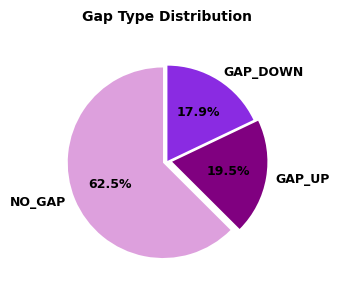

In [140]:
print("\n\nGAP UP-GAP DOWN ANALYSIS")
print("-"*60)

print("Gap Type Distribution:")
gap_distribution = df['Gap_Type'].value_counts()
gap_percentage = (df['Gap_Type'].value_counts(normalize=True) * 100).round(2)

for gap_type, count in gap_distribution.items():
    pct = gap_percentage[gap_type]
    print(f"  {gap_type}: {count:,} days ({pct:.2f}%)")

print(f"\nGap Percentage Statistics:")
print(f"  Average Gap: {df['Gap_Percent'].mean():.2f}%")
print(f"  Max Gap Up: {df['Gap_Percent'].max():.2f}%")
print(f"  Max Gap Down: {df['Gap_Percent'].min():.2f}%")
print(f"  Std Dev: {df['Gap_Percent'].std():.2f}%")

# Visualization
fig, ax = plt.subplots(figsize=(6, 3))

gap_counts = df['Gap_Type'].value_counts()
colors_gap = ['#DDA0DD', '#800080', '#8A2BE2']
explode = (0.05, 0.05, 0)

wedges, texts, autotexts = ax.pie(
    gap_counts.values,
    labels=gap_counts.index,
    autopct='%1.1f%%',
    colors=colors_gap,
    explode=explode,
    startangle=90,
    textprops={'fontsize': 9, 'weight': 'bold'}
)

ax.set_title('Gap Type Distribution', fontsize=10, fontweight='bold', pad=15)

for autotext in autotexts:
    autotext.set_color('black')

plt.tight_layout()
plt.show()

*-----------------------------------------------------------------------------------------------------------------------------------------------------*

**DAY-OF-WEEK EFFECT**

**Problem: Analyze if specific weekdays show consistent return patterns.**

**Question: Which days have best/worst average returns?**



DAY-OF-WEEK EFFECT
------------------------------------------------------------
Daily Average Returns by Day of Week:
                 mean
Day_of_Week_Cat      
Monday          -0.03
Tuesday         -0.05
Wednesday       -0.03
Thursday         0.00
Friday          -0.05

Key Findings:
  Best Day: Thursday (0.00%)
  Worst Day: Tuesday (-0.05%)
  Difference: 0.05%


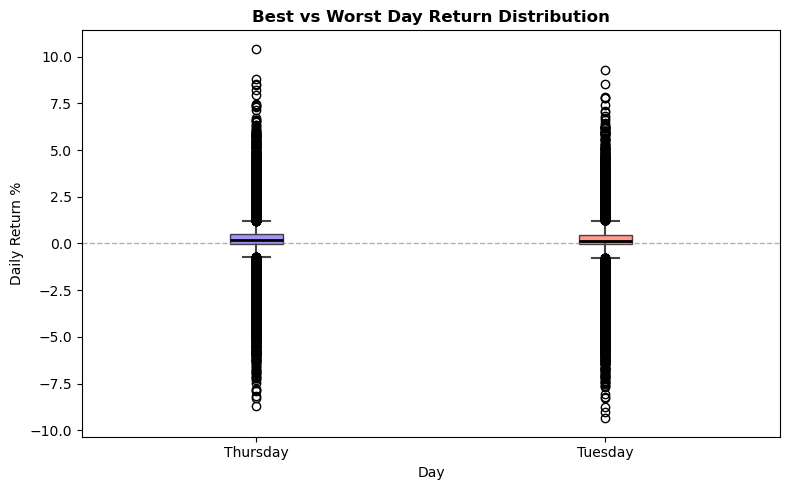

In [177]:
print("\n\nDAY-OF-WEEK EFFECT")
print("-"*60)

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']
df['Day_of_Week_Cat'] = pd.Categorical(df['Day_of_Week'], categories=day_order, ordered=True)

print("Daily Average Returns by Day of Week:")
day_of_week_returns = df.groupby('Day_of_Week_Cat')['Daily_Return_Percent'].agg(['mean']).round(2)
print(day_of_week_returns)

best_day = day_of_week_returns['mean'].idxmax()
worst_day = day_of_week_returns['mean'].idxmin()

print(f"\nKey Findings:")
print(f"  Best Day: {best_day} ({day_of_week_returns.loc[best_day, 'mean']:.2f}%)")
print(f"  Worst Day: {worst_day} ({day_of_week_returns.loc[worst_day, 'mean']:.2f}%)")
print(f"  Difference: {day_of_week_returns.loc[best_day, 'mean'] - day_of_week_returns.loc[worst_day, 'mean']:.2f}%")

# Visualization - Boxplot
# Only best & worst days
selected_days = [best_day, worst_day]

boxplot_data_days = [
    df[df['Day_of_Week_Cat'] == day]['Daily_Return_Percent'].dropna().values
    for day in selected_days
]

fig, ax = plt.subplots(figsize=(8, 5)) 

bp = ax.boxplot(boxplot_data_days,
                labels=selected_days,
                patch_artist=True)
# Colors
colors = ['#7B68EE', '#FF6F61'] 

for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

for whisker in bp['whiskers']:
    whisker.set(color='#444', linewidth=1.5)
for cap in bp['caps']:
    cap.set(color='#444', linewidth=1.5)

# Median line
for median in bp['medians']:
    median.set(color='black', linewidth=2)

# Zero line
ax.axhline(y=0, color='gray', linestyle='--', linewidth=1, alpha=0.6)

ax.set_title('Best vs Worst Day Return Distribution', fontsize=12, fontweight='bold')
ax.set_ylabel('Daily Return %')
ax.set_xlabel('Day')

plt.tight_layout()
plt.show()

**MONTHLY RETURN TRENDS**

**Problem: Identify seasonal patterns in returns across months.**
    
**Question: Which months show best/worst performance?**



MONTHLY RETURN TRENDS
------------------------------------------------------------
Daily Returns by Month:
            mean  median   std  count
Month_Name                           
January    -0.09    0.15  1.56   5750
February   -0.06    0.15  1.53   5000
March      -0.05    0.16  1.47   5000
April      -0.07    0.14  1.46   4750
May         0.01    0.17  1.44   5500
June       -0.03    0.15  1.51   5250
July       -0.01    0.15  1.45   5750
August     -0.01    0.16  1.52   4750
September   0.03    0.16  1.52   5500
October    -0.04    0.16  1.55   5250
November   -0.07    0.15  1.53   4500
December    0.02    0.17  1.49   5500

Key Findings:
  Best Month: September (0.03%)
  Worst Month: January (-0.09%)

Cumulative Monthly Returns:
  January: -504.61%
  February: -294.66%
  March: -243.29%
  April: -324.24%
  May: +72.62%
  June: -182.60%
  July: -67.90%
  August: -69.80%
  September: +137.73%
  October: -205.64%
  November: -316.08%
  December: +93.13%


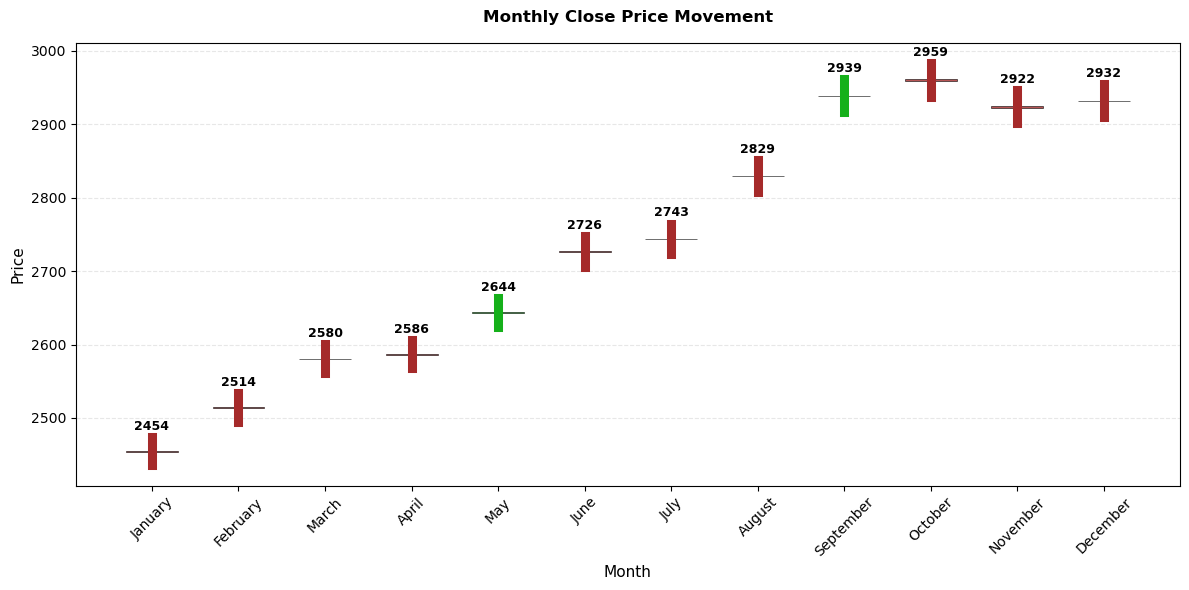

In [158]:
print("\n\nMONTHLY RETURN TRENDS")
print("-"*60)

month_order = ['January', 'February', 'March', 'April', 'May', 'June', 
               'July', 'August', 'September', 'October', 'November', 'December']

print("Daily Returns by Month:")
monthly_returns = df.groupby('Month_Name')['Daily_Return_Percent'].agg(['mean', 'median', 'std', 'count']).round(2)
monthly_returns = monthly_returns.reindex([m for m in month_order if m in monthly_returns.index])
print(monthly_returns)

best_month = monthly_returns['mean'].idxmax()
worst_month = monthly_returns['mean'].idxmin()

print(f"\nKey Findings:")
print(f"  Best Month: {best_month} ({monthly_returns.loc[best_month, 'mean']:.2f}%)")
print(f"  Worst Month: {worst_month} ({monthly_returns.loc[worst_month, 'mean']:.2f}%)")

print(f"\nCumulative Monthly Returns:")
monthly_cumulative_returns = df.groupby('Month')['Daily_Return_Percent'].sum().round(2)
for month_num in sorted(monthly_cumulative_returns.index):
    month_name = month_order[int(month_num)-1]
    sign = "+" if monthly_cumulative_returns[month_num] > 0 else ""
    print(f"  {month_name}: {sign}{monthly_cumulative_returns[month_num]:.2f}%")

# Visualization - Candlestick Chart
monthly_ohlc = df.groupby('Month').agg({
    'Open': 'mean',
    'High': 'mean',
    'Low': 'mean',
    'Close': 'mean'
}).round(2)

fig, ax = plt.subplots(figsize=(12, 6))

width = 0.6
up_color = '#15B01A'    
down_color = '#A52A2A'
gap = 10  
for idx, month in enumerate(sorted(monthly_ohlc.index), 1):
    open_price = monthly_ohlc.loc[month, 'Open']
    close_price = monthly_ohlc.loc[month, 'Close']
    high_price = monthly_ohlc.loc[month, 'High']
    low_price = monthly_ohlc.loc[month, 'Low']

    color = up_color if close_price >= open_price else down_color

    # Wick (high-low line)
    ax.plot([idx, idx], [low_price, high_price],
            color=color, linewidth=6.5)

    # Body
    height = abs(close_price - open_price)
    bottom = min(open_price, close_price)

    ax.bar(idx, height, width,
           bottom=bottom,
           color=color,
           edgecolor='black',
           linewidth=0.5,
           alpha=0.8)

    # Data label (Close price)
    ax.text(idx,
            high_price + gap,     
            f'{close_price:.0f}',
            ha='center',
            fontsize=9,
            fontweight='bold')

# Axis settings
ax.set_xticks(range(1, len(monthly_ohlc) + 1))
ax.set_xticklabels([month_order[int(m)-1] for m in sorted(monthly_ohlc.index)],
                   rotation=45)

ax.set_title('Monthly Close Price Movement',
             fontsize=12, fontweight='bold', pad=15)

ax.set_ylabel('Price', fontsize=11)
ax.set_xlabel('Month', fontsize=11)

ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

*-----------------------------------------------------------------------------------------------------------------------------------------------------*

**PRICE VS 52-WEEK RANGE**
    
**Problem: Calculate how far current price is from 52-week highs and lows.**

**Question: What percentage distance is price from 52-week extremes?**

In [157]:
print("\n\nPRICE VS 52-WEEK RANGE")
print("-"*60)

df['Distance_from_52W_High_Pct'] = ((df['52_Week_High'] - df['Close']) / df['52_Week_High'] * 100).round(2)
df['Distance_from_52W_Low_Pct'] = ((df['Close'] - df['52_Week_Low']) / df['52_Week_Low'] * 100).round(2)

print("Distance from 52-Week High:")
print(f"  Average: {df['Distance_from_52W_High_Pct'].mean():.2f}%")
print(f"  Max: {df['Distance_from_52W_High_Pct'].max():.2f}%")
print(f"  Min: {df['Distance_from_52W_High_Pct'].min():.2f}%")

print(f"\nDistance from 52-Week Low:")
print(f"  Average: {df['Distance_from_52W_Low_Pct'].mean():.2f}%")
print(f"  Max: {df['Distance_from_52W_Low_Pct'].max():.2f}%")
print(f"  Min: {df['Distance_from_52W_Low_Pct'].min():.2f}%")

print(f"\nCompanies Closest to 52-Week High:")
company_52w_high = df.groupby('Company')['Distance_from_52W_High_Pct'].mean().sort_values()
print(company_52w_high.head(10).round(2))




PRICE VS 52-WEEK RANGE
------------------------------------------------------------
Distance from 52-Week High:
  Average: 18.69%
  Max: 64.03%
  Min: 0.00%

Distance from 52-Week Low:
  Average: 39.83%
  Max: 343.01%
  Min: 0.00%

Companies Closest to 52-Week High:
Company
SUNPHARMA      4.90
SBIN           8.62
SBILIFE        8.76
NTPC           9.37
BHARTIARTL     9.83
WIPRO          9.90
GRASIM        10.19
DRREDDY       10.49
POWERGRID     10.77
COLPAL        10.78
Name: Distance_from_52W_High_Pct, dtype: float64


*-----------------------------------------------------------------------------------------------------------------------------------------------------*

**VOLATILITY TREND**
  
**Problem: Track volatility changes over time.**
    
**Question: How does volatility change across the month?**



VOLATILITY TREND
------------------------------------------------------------

Monthly Avg Volatility:
Month_Name
January      1.56
February     1.55
March        1.53
April        1.50
May          1.51
June         1.53
July         1.51
August       1.55
September    1.54
October      1.57
November     1.55
December     1.54
Name: Intraday_Vol, dtype: float64


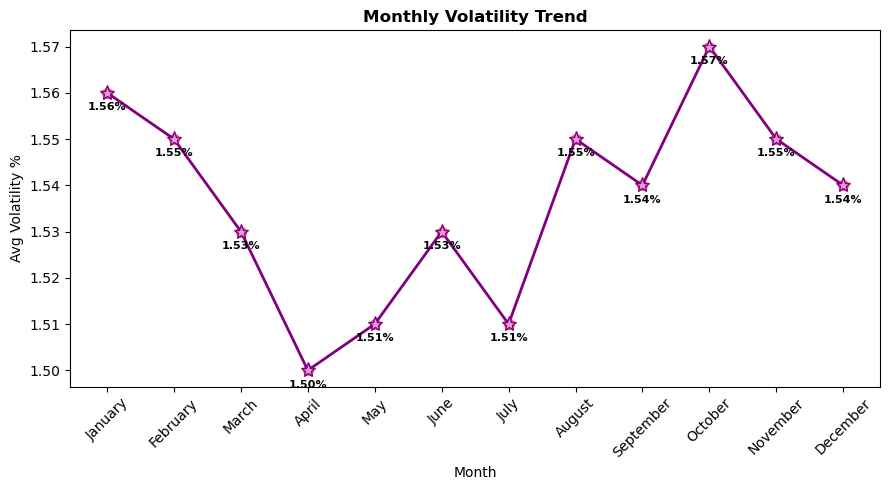

In [182]:
print("\n\nVOLATILITY TREND")
print("-"*60)

df['Intraday_Vol'] = ((df['High'] - df['Low']) / df['Open'] * 100).round(2)

month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']

# Month-wise average volatility
monthly_vol = df.groupby('Month_Name')['Intraday_Vol'].mean().round(2)

monthly_vol = monthly_vol.reindex([m for m in month_order if m in monthly_vol.index])

print("\nMonthly Avg Volatility:")
print(monthly_vol)

# Vizualizatiomn
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(monthly_vol.index,
        monthly_vol.values,
        marker='*',
        linewidth=2,
        color='#800080',
        markersize=11,
        markerfacecolor = '#DDA0DD')

ax.grid(False)

ax.set_title('Monthly Volatility Trend', fontsize=12, fontweight='bold')
ax.set_ylabel('Avg Volatility %', fontsize=10)
ax.set_xlabel('Month', fontsize=10)

plt.xticks(rotation=45)

for i, v in enumerate(monthly_vol.values):
    ax.text(i,
            v - 0.002,   
            f'{v:.2f}%',
            ha='center',
            va='top',
            fontsize=8,
            fontweight='bold')

ax.scatter(monthly_vol.index,
           monthly_vol.values,
           color='#FF6F61',
           s=50)

plt.tight_layout()
plt.show()

*-----------------------------------------------------------------------------------------------------------------------------------------------------*

**VOLUME DISTRIBUTION**
  
**Problem: Analyze how volume is distributed.**

**Question: What's the distribution of trading volumes?**



VOLUME DISTRIBUTION
------------------------------------------------------------
Avg Volume: 112,844
Median Volume: 89,563
Max Volume: 499,988
Min Volume: 5,000


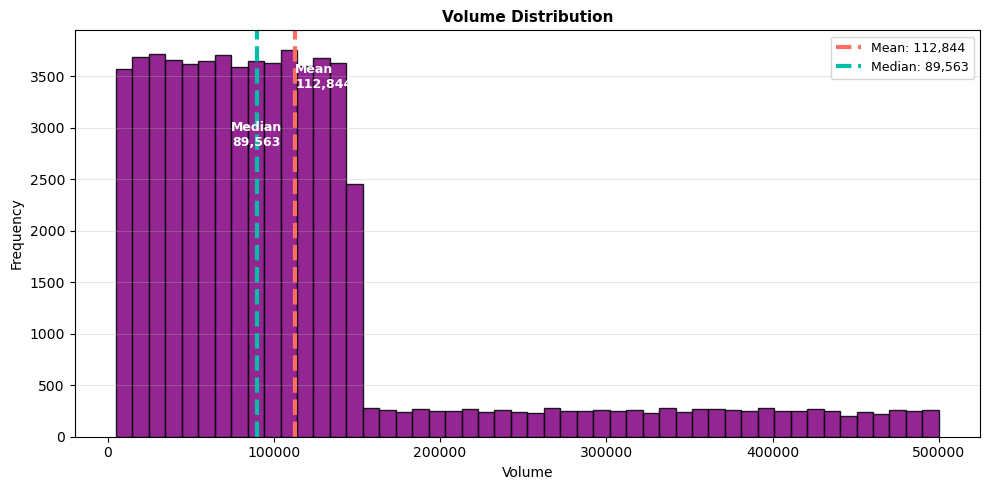

In [181]:
print("\n\nVOLUME DISTRIBUTION")
print("-"*60)
mean_val = df['Volume'].mean()
median_val = df['Volume'].median()

print(f"Avg Volume: {mean_val:,.0f}")
print(f"Median Volume: {median_val:,.0f}")
print(f"Max Volume: {df['Volume'].max():,.0f}")
print(f"Min Volume: {df['Volume'].min():,.0f}")

fig, ax = plt.subplots(figsize=(10, 5))

hist_color = '#800080'        # main bar color
mean_color = '#FF6F61'        # mean line
median_color = '#00BFA6'      # median line

# Histogram
counts, bins, patches = ax.hist(df['Volume'],
                                bins=50,
                                color=hist_color,
                                edgecolor='black',
                                alpha=0.85)

# Mean & Median lines
ax.axvline(mean_val, color=mean_color, linestyle='--', linewidth=3,
           label=f'Mean: {mean_val:,.0f}')

ax.axvline(median_val, color=median_color, linestyle='--', linewidth=3,
           label=f'Median: {median_val:,.0f}')

# Data labels (Mean & Median position text)
y_max = counts.max()

ax.text(mean_val,
        y_max * 0.9,
        f'Mean\n{mean_val:,.0f}',
        color='white',
        ha='left',
        fontsize=9,
        fontweight='bold')

ax.text(median_val,
        y_max * 0.75,
        f'Median\n{median_val:,.0f}',
        color='white',
        ha='center',
        fontsize=9,
        fontweight='bold')

# Titles
ax.set_title('Volume Distribution', fontsize=11, fontweight='bold')
ax.set_xlabel('Volume', fontsize=10)
ax.set_ylabel('Frequency', fontsize=10)

ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

*-----------------------------------------------------------------------------------------------------------------------------------------------------*

# <center> **DASHBOARD - 2** </center>

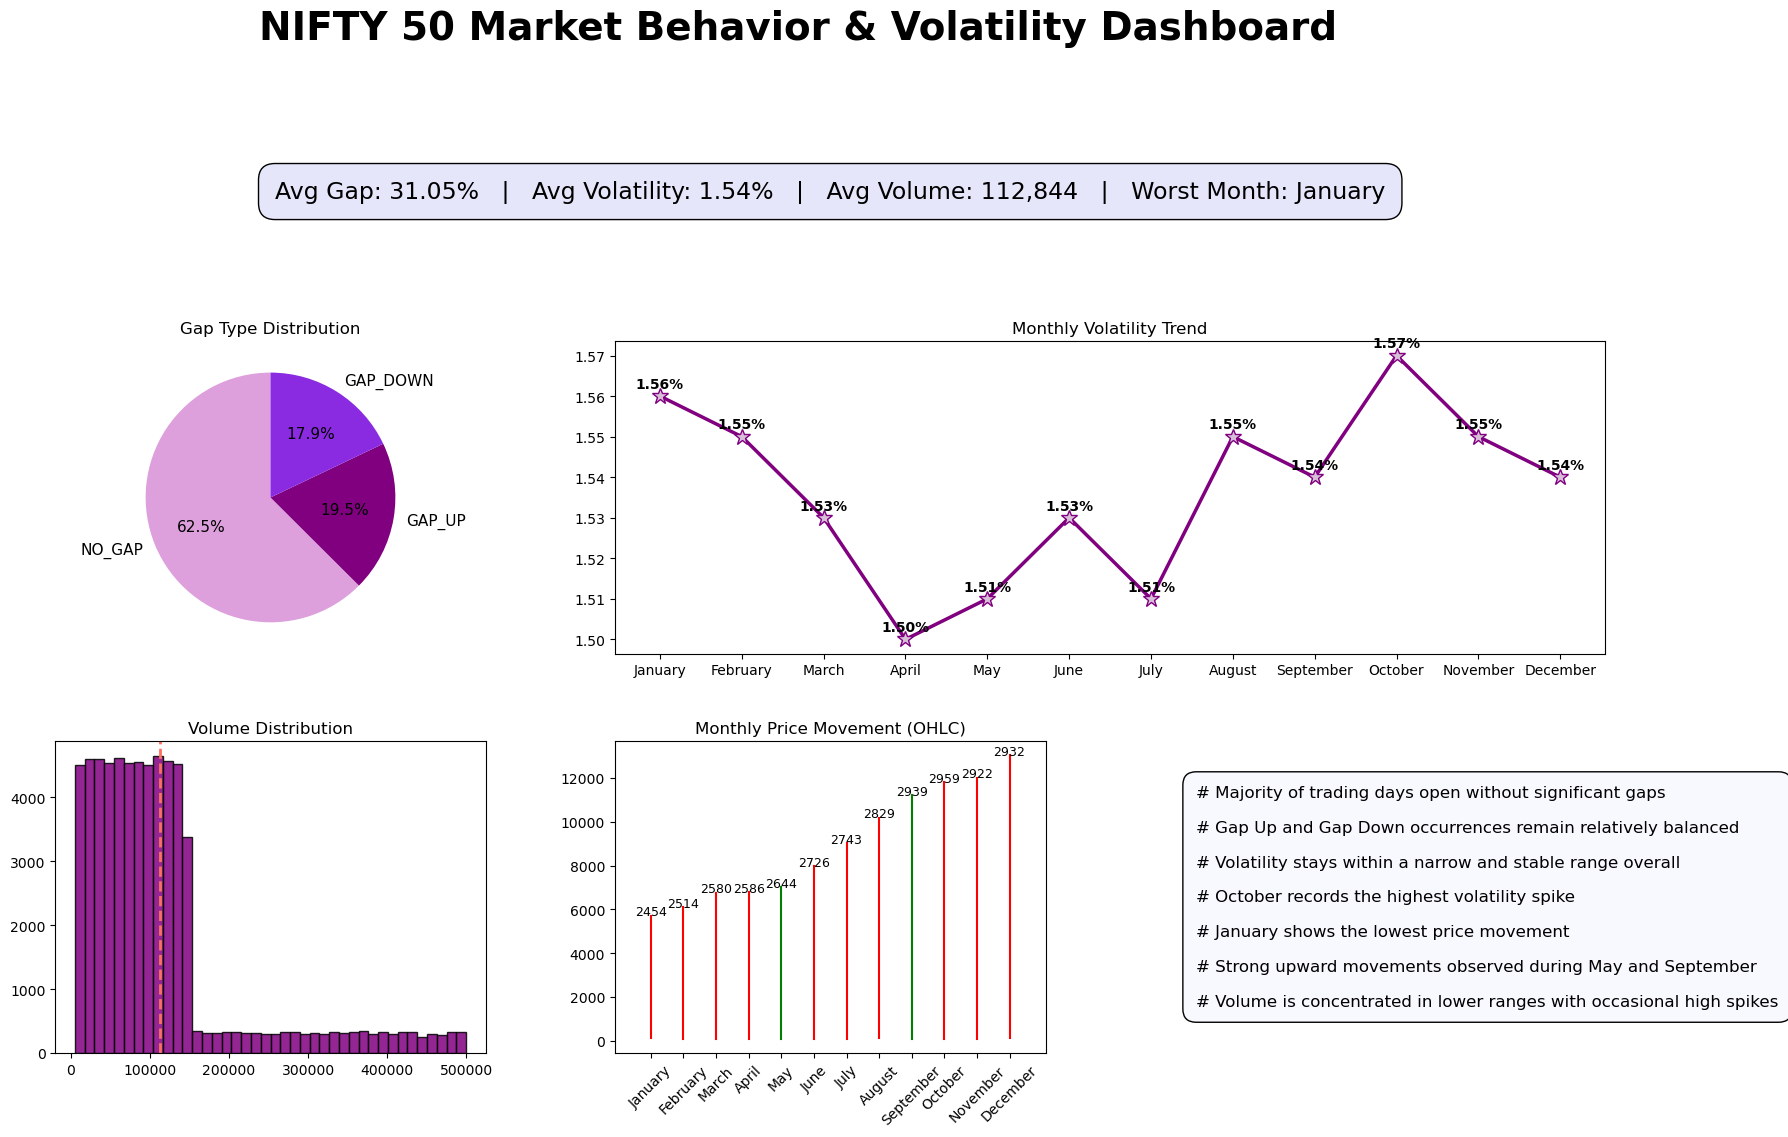

In [206]:
# ---------------------------------------- DASHBOARD - 2 ----------------------------------------#
# -------------- COLORS ---------------------
color_main = '#800080'
color_light = '#D8BFD8'
# ------------- KPI VALUES -------------------
avg_gap = df['Gap_Percent'].mean()
avg_volatility = df['Intraday_Vol'].mean()
avg_volume = df['Volume'].mean()
worst_month = monthly_returns['mean'].idxmin()

# ------------------------ MONTH ORDER -------------------------
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']

monthly_vol = monthly_vol.reindex(month_order)
monthly_ohlc = df.groupby('Month_Name').agg({
    'Open': 'mean',
    'High': 'max',
    'Low': 'min',
    'Close': 'mean'
}).reindex(month_order)

# --------------- FIGURE ------------------
fig = plt.figure(figsize=(20, 12))
fig.suptitle("NIFTY 50 Market Behavior & Volatility Dashboard ",
             fontsize=28, fontweight='bold')

gs = fig.add_gridspec(3, 3, height_ratios=[0.4, 1, 1],
                      hspace=0.35, wspace=0.3)

# ---------------- KPI ------------------
ax_kpi = fig.add_subplot(gs[0, :])
ax_kpi.axis('off')

kpi_text = (
    f"Avg Gap: {avg_gap:.2f}%   |   "
    f"Avg Volatility: {avg_volatility:.2f}%   |   "
    f"Avg Volume: {avg_volume:,.0f}   |   "
    f"Worst Month: {worst_month}"
)

ax_kpi.text(0.5, 0.5, kpi_text,
            ha='center', va='center',
            fontsize=17,
            bbox=dict(facecolor='#E6E6FA',
                      boxstyle='round,pad=0.7'))

# -------------- (1) PIE ----------------
ax1 = fig.add_subplot(gs[1, 0])

gap_counts = df['Gap_Type'].value_counts()

ax1.pie(gap_counts,
        labels=gap_counts.index,
        autopct='%1.1f%%',
        colors=['#DDA0DD', '#800080', '#8A2BE2'],
        startangle=90,
        textprops={'fontsize':11})

ax1.set_title("Gap Type Distribution", fontsize=12)

# --------------- (2) LINE ----------------
ax2 = fig.add_subplot(gs[1, 1:3])

ax2.plot(monthly_vol.index,
         monthly_vol.values,
         marker='*',
         markersize=12,
         linewidth=2.5,
         color=color_main,
         markerfacecolor=color_light)

for i, v in enumerate(monthly_vol.values):
    ax2.text(i, v + 0.002,
             f'{v:.2f}%',
             ha='center',
             fontsize=10,
             fontweight='bold')

ax2.set_title("Monthly Volatility Trend", fontsize=12)
ax2.grid(False)

# -------------- (3) HIST ------------------
ax3 = fig.add_subplot(gs[2, 0])

mean_val = df['Volume'].mean()

ax3.hist(df['Volume'], bins=40,
         color=color_main,
         edgecolor='black',
         alpha=0.85)

ax3.axvline(mean_val, color='#FF6F61', linestyle='--', linewidth=2)

ax3.set_title("Volume Distribution", fontsize=12)

#------------------ (4) CANDLE -------------------
ax4 = fig.add_subplot(gs[2, 1])

months = monthly_ohlc.index

for i, m in enumerate(months):
    o = monthly_ohlc.loc[m, 'Open']
    c = monthly_ohlc.loc[m, 'Close']
    h = monthly_ohlc.loc[m, 'High']
    l = monthly_ohlc.loc[m, 'Low']

    color = 'green' if c >= o else 'red'

    ax4.plot([i, i], [l, h], color=color, linewidth=1.5)
    ax4.bar(i, abs(c-o), bottom=min(o, c),
            color=color, width=1)

    ax4.text(i, h + 10, f'{c:.0f}',
             ha='center', fontsize=9)

ax4.set_xticks(range(len(months)))
ax4.set_xticklabels(months, rotation=45)
ax4.set_title("Monthly Price Movement (OHLC)", fontsize=12)

# (5) ------------------- INSIGHT BOX --------------------------
ax5 = fig.add_subplot(gs[2, 2])
ax5.axis('off')
insight_text = (
    "# Majority of trading days open without significant gaps\n\n"
    "# Gap Up and Gap Down occurrences remain relatively balanced\n\n"
    "# Volatility stays within a narrow and stable range overall\n\n"
    "# October records the highest volatility spike\n\n"
    "# January shows the lowest price movement\n\n"
    "# Strong upward movements observed during May and September\n\n"
    "# Volume is concentrated in lower ranges with occasional high spikes"
)

ax5.text(0.05, 0.5, insight_text,
         va='center',
         fontsize=12,
         bbox=dict(facecolor='#F8F8FF',
                   edgecolor='black',
                   boxstyle='round,pad=0.8'))

# --------------- FINAL ----------------
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


*<center>--------------------------------------------------------------------------------------------------------------</center>*